<a href="https://colab.research.google.com/github/ryanglenc/MAT_442/blob/main/MAT_442_1_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.set_printoptions(precision=4, suppress=True)

## 1.4.1 Singular Value Decomposition

Any matrix A (m x n) can be factored as A = U Σ V^T, where:
- U (m x m) has orthonormal columns (left singular vectors)
- Σ (m x n) is diagonal, with non-negative singular values in decreasing order
- V (n x n) has orthonormal columns (right singular vectors)

We'll compute the SVD of a small matrix and verify the reconstruction.

In [2]:
A = np.array([[4, 0],
              [3, -5],
              [0, 2]], dtype=float)

U, S, Vt = np.linalg.svd(A)

print("U (left singular vectors):\n", U)
print("\nSingular values:", S)
print("\nV^T (right singular vectors, transposed):\n", Vt)

# Reconstruct Sigma as a full m x n matrix
Sigma = np.zeros_like(A)
np.fill_diagonal(Sigma, S)

A_reconstructed = U @ Sigma @ Vt
print("\nReconstructed A:\n", A_reconstructed)
print("Matches original A:", np.allclose(A, A_reconstructed))

U (left singular vectors):
 [[-0.4059  0.8736 -0.2683]
 [-0.884  -0.3009  0.3578]
 [ 0.2318  0.3824  0.8944]]

Singular values: [6.491  3.4449]

V^T (right singular vectors, transposed):
 [[-0.6587  0.7524]
 [ 0.7524  0.6587]]

Reconstructed A:
 [[ 4.  0.]
 [ 3. -5.]
 [ 0.  2.]]
Matches original A: True


## 1.4.2 Low-Rank Matrix Approximations

By the Eckart–Young theorem, the best rank-k approximation of A (in terms of minimizing reconstruction error) is obtained by keeping only the top k singular values/vectors from the SVD and zeroing out the rest.

We'll build a slightly larger matrix, compute its rank-1 approximation, and measure the approximation error.

In [3]:
B = np.array([[3, 1, 2],
              [2, 4, 1],
              [1, 0, 5],
              [4, 2, 3]], dtype=float)

U, S, Vt = np.linalg.svd(B, full_matrices=False)
print("Singular values of B:", S)

# Rank-1 approximation: keep only the largest singular value
k = 1
B_approx = U[:, :k] @ np.diag(S[:k]) @ Vt[:k, :]

print(f"\nRank-{k} approximation of B:\n", B_approx)

# Error between original and approximation (Frobenius norm)
error = np.linalg.norm(B - B_approx, 'fro')
print(f"\nApproximation error (Frobenius norm): {error:.4f}")

# Compare to a rank-2 approximation
k2 = 2
B_approx2 = U[:, :k2] @ np.diag(S[:k2]) @ Vt[:k2, :]
error2 = np.linalg.norm(B - B_approx2, 'fro')
print(f"Rank-{k2} approximation error: {error2:.4f} (should be smaller)")

Singular values of B: [8.3363 4.0825 1.9592]

Rank-1 approximation of B:
 [[2.2386 1.4748 2.4157]
 [2.1991 1.4488 2.373 ]
 [2.4612 1.6215 2.6559]
 [3.2923 2.169  3.5526]]

Approximation error (Frobenius norm): 4.5283
Rank-2 approximation error: 1.9592 (should be smaller)


## 1.4.3 Principal Component Analysis

PCA finds the directions (principal components) along which data varies the most. Steps:
1. Center the data (subtract the mean of each feature).
2. Compute the SVD (or eigendecomposition of the covariance matrix) of the centered data.
3. The right singular vectors (or eigenvectors of the covariance matrix) are the principal components.

We'll generate a small 2D dataset, find its principal components, and project the data onto the first component.

Principal components (directions):
 [[-0.5179 -0.8555]
 [-0.8555  0.5179]]

Singular values: [24.6736  3.2226]
Explained variance ratio: [0.9832 0.0168]


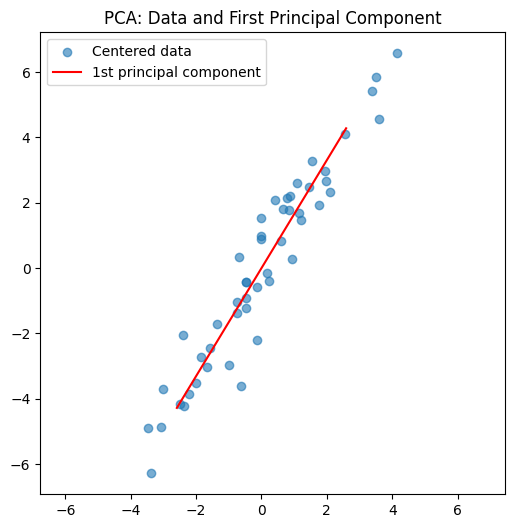


First PC explains 98.3% of the variance.


In [4]:
# Small 2D dataset with correlated features
np.random.seed(42)
n_points = 50
x = np.random.normal(0, 2, n_points)
y = 1.5 * x + np.random.normal(0, 1, n_points)
data = np.column_stack((x, y))

# Step 1: center the data
data_centered = data - data.mean(axis=0)

# Step 2: SVD of centered data
U, S, Vt = np.linalg.svd(data_centered, full_matrices=False)

# Principal components are rows of Vt
print("Principal components (directions):\n", Vt)
print("\nSingular values:", S)

# Explained variance ratio
explained_variance = (S ** 2) / np.sum(S ** 2)
print("Explained variance ratio:", explained_variance)

# Step 3: project data onto the first principal component
pc1 = Vt[0]
projected = data_centered @ pc1

# Plot original data with principal component direction
plt.figure(figsize=(6, 6))
plt.scatter(data_centered[:, 0], data_centered[:, 1], alpha=0.6, label='Centered data')
scale = 5
plt.plot([-scale*pc1[0], scale*pc1[0]], [-scale*pc1[1], scale*pc1[1]],
         color='red', label='1st principal component')
plt.axis('equal')
plt.legend()
plt.title('PCA: Data and First Principal Component')
plt.show()

print(f"\nFirst PC explains {explained_variance[0]*100:.1f}% of the variance.")